# Search for Sastrugi

## Kas Knicely, University of Alaska Fairbanks

This notebook searches Sentinel 1 SAR imagery for possible sastrugi locations. This was created in support of the CCREL Arctic Trafficability Project. 

This was created with radiometrically terrain corrected (RTC) SAR imagery in mind, though - strictly speaking - non-RTC SAR imagery can be used as well. The non-RTC SAR imagery will only work in this tool <b>if</b> it was taken by the same sensor from the same look angle and has pixel locations that match each other. This is because a difference calculation is used to locate the possible sastrgui. 

To incorporate SAR imagery from MULTIPLE sensor sources (e.g., Sentinel 1 and plane-mounted), the data <b>must be</b> RTC. 

Approximate Date of Creation: 2026 March 20

## Brief Background on Sastrugi

Sastrugi are erosional snow features formed by the sintering of snow followed by removal of loose material by wind. Sastrugi are often described as wave-like. 

Although sastrugi are difficult terrain to cross, they are preferrable terrains as they are less likely to experience collapse and avalanches. 

As sastrugi are caused by sintering and subsequent removal of loose snow, this code looks through a time series of data for an increase in VV paired with a decrease in VH. The increase in VV is caused by 1) sintering of the snow into a contiguous surface, and 2) removal of loose snow that causes volume scattering (and hence redistributes energy from vertical polarization to other polarizations). The decrease in VH is caused by 1) sintering of snow preventing VV signal from getting deeper into the snow and hence volume scattering, and 2) removal of loose snow that causes volume scattering. 

<b>This methodology is THEORETICAL!!!</b>. It has neither been tested nor ground-truthed. 

***
# 0. Load Python Libraries

Load necessary libraries. 

In [1]:
# Confirmed Necessary
import xarray as xr
from pathlib import Path
import pandas as pd
import glob
import re
import os
import rasterio
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
# Possibly Necessary
import rioxarray as rxr
import time
import numpy as np
import time
from pyproj import Transformer
from datetime import date
import itertools
from scipy import signal

Install necessary libraries that are not included in the base kernel. 

In [2]:
!pip install ipyfilechooser

  Using cached ipyfilechooser-0.6.0-py3-none-any.whl.metadata (6.4 kB)
Using cached ipyfilechooser-0.6.0-py3-none-any.whl (11 kB)


In [3]:
# Install and import skimage
!pip install scikit-image
from skimage.measure import label

  Using cached scikit_image-0.26.0-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (15 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
Using cached scikit_image-0.26.0-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (13.7 MB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-image] [scikit-image]


In [4]:
!pip install simplekml
import simplekml

  Using cached simplekml-1.3.6-py3-none-any.whl


***
# 1. User Settings

## 1.1 Select folder from which to load S1 SAR Imagery

This should be the folder containing the subsetted imagery of your region of interest. These files should be in a folder named 'RTC_GAMMA'. 

For example: <br>
Subsets were placed in a folder named 'subsets'. This folder should contain a folder named 'RTC_GAMMA' which will contain your subsetted tiffs. To run the below code, you will select the folder 'subsets'. 

In [5]:
from ipyfilechooser import FileChooser
fc = FileChooser(Path.cwd())
display(fc)

FileChooser(path='/home/jovyan/CRREL/OverflowDetection', filename='', title='', show_hidden=False, select_desc…

## 1.2 Select thresholds and data to include

Please select the minimum changes in backscatter to flag a pixel as a potential location for overflow. 

min_pos - smallest positive change prior to the drop in backscatter. <br>
min_neg - smallest negative change to backscatter. 

start_ind - first index of data to include. In python, index of 0 is the first. <br>
stop_ind  - last index of data to include. Setting this to -1 will include the very last SAR acquisition.

For example, <br>start_ind = 0 and stop_ind = -1 will include all data. <br>start_ind = 1 and stop_ind = 3 will include the 2nd, 3rd, and 4th set of data. 

In [47]:
# set delta_dB thresholds. 
delta_VV = [1.0,]
delta_VH = [-1.0,]
# make sure 'delat_VV' and 'delta_VH' are lists
if not isinstance(delta_VV, list):
    delta_VV = [delta_VV]
    print(f"delta_VV converted to list.")
if not isinstance(delta_VH, list):
    delta_VH = [delta_VH]
    print(f"delta_VV converted to list.")
# Make sure 'delta_VV' and 'delta_VH' are the same length. 
if len(delta_VV) != len(delta_VH):
    print(f"WARNING!!!\nWARNING!!!\nWARNING!!!\n")
    print(f"Number of delta_VV and delta_VH values are different!")
    print(f"Please ensure the delta_VV and delta_VH are the same length.\n")


# Set start and stop indices. This is useful if you are dealing with e.g., several months of data that includes time that can't possibly have overflow. 
start_ind = -3
stop_ind = -1

print(f"start_ind: {start_ind}\nstop_ind:  {stop_ind}")

start_ind: -3
stop_ind:  -1


Select window size for overflow search. This is used to give more robust detections. The larger this value, the faster searches will proceed, but at the cost of missing smaller overflow features. 

In [8]:
### --- Set up window sizes for search through SAR imagery --- ###

window_sizes = [3] # window sizes; must be odd value.
if not isinstance(window_sizes, list):
    window_sizes = [window_sizes]
    print("window_sizes converted to list.") 
for i in range(len(window_sizes)): 
    if window_sizes[i] % 2 != 0:
        continue
    else: 
        print("WARNING!!!\nWARNING!!!\nWARNING!!!\nWindow sizes must be odd. Increasing value by 1.")
        window_sizes[i] = window_sizes[i]+1

# remove duplicates. 
window_sizes = list(set(window_sizes))
window_sizes.sort()

Set median filter to apply to the raw data. This is often a standard step when using SAR imagery to reduce its inherently noisy nature. 

In [9]:
median_size = 3
if median_size % 2 != 0:
    pass
else:
    print("WARNING!!!\nWARNING!!!\nWARNING!!!\nMedian filter size must be odd. Increasing value by 1.")
    median_size = median_size + 1
    print(f"median_size = {median_size}")

## 1.3 Select minimum (and maximum) size of possible overflow locations to include

Please select the minimum number of touching pixels (min_pixels) for your overflow region. Note that the maximum may also be selected. 

In [10]:
# Typical overflow event are approximately 15 S1 pixels in size. 
min_pixels = 4
max_pixels = float('inf')

## 1.4 Set kml and geotiff save settings

Select the location in which to save the files. This is often best set to the same thing as the load location. 

In [11]:
fc_saveLoc = FileChooser(Path.cwd())
display(fc_saveLoc)

FileChooser(path='/home/jovyan/CRREL/OverflowDetection', filename='', title='', show_hidden=False, select_desc…

Select the save name for the geotiff. The default is 'overflow_[date of creation].tif'. The default name will be used when teh saveName is set to None. 

For example, <br>
saveOverflowAsGeotiff(fc, fc_saveLoc, da_VV_tot[0], myIndices_both, saveName = 'TananaRiverOverflow')

In [12]:
saveName = None
# saveName = 'myCustomSaveName'

## 1.5 Note about Section 6. 

Section 6. can display data for a specific location as identified in section 5. The default code will display the first location for the most stringent threshold applied. To change this, the user must go to section 6. and select a different location manually. 

***
# 2. Load Sentinel 1 SAR Imagery

In [13]:
### --- Get Dates from filenames --- ###
def get_dates(flnms):
    dates = []

    for flnm in flnms:
        date_regex = r'\d{8}'
        date = re.search(date_regex, str(flnm))
        if date:
            dates.append(date.group(0))
    return dates


### --- Load Geotiffs Function --- ###
def load_tiffs(parent, type_file, pola, stop_ind = -1):

    # Load the appropriate files
    if type_file == 'SAR':
        folder = parent+'RTC_GAMMA/'
        prefix = f'*{pola}'
    else:
        folder = parent+'Water_Masks/'
        prefix = '*combined'

    # Gather names of files corresponding to the file type and polarization we want
    tiff_dir = Path(folder)
    tiffs = [f for f in os.listdir(tiff_dir) if pola in f]
    
    # Gather the date of each file
    times = get_dates(tiffs)

    # Make 'tiffs' have full path
    tiffs = [Path(folder,tiff) for tiff in tiffs]
    
    # Create a list of indices based on the sorted order of times
    sorted_indices = sorted(range(len(times)), key=lambda i: times[i])
    
    # Sort the paths based on the times
    tiffs = [tiffs[i] for i in sorted_indices]
    
    # Sort the times axisdd
    times.sort()
    times = pd.DatetimeIndex(times)
    times.name = "time"
    
    # Create the dataset gathering the input images
    if stop_ind == -1:
        stop_ind = len(tiffs)
    da = xr.concat([rxr.open_rasterio(Path(tiff_dir,f)).squeeze(dim='band') for f in tiffs[:stop_ind]], dim=times[:stop_ind])
    da = da.drop_vars(['band', 'spatial_ref'])

    print(f"Dataset size in memory: {da.nbytes / 1e6:.2f} MB")

    return da, tiffs, times

In [14]:
### --- Load data --- ###
# da_tot - Xarray containing all of the data. 
# tiffPaths_tot - posix paths array containing paths to all data files. 
# times_tot - list containing all of the dates of each data (note: this will also be in 'da_tot').

type_file = 'SAR'

# # Load VV tiffs
pola = 'VV' 
da_VV_tot, tiffPaths_VV_tot, times_VV_tot = load_tiffs(fc.selected, type_file, pola, stop_ind = -1)

# Load VH tiffs
pola = 'VH'
da_VH_tot, tiffPaths_VH_tot, times_VH_tot = load_tiffs(fc.selected, type_file, pola, stop_ind = -1)

Dataset size in memory: 65.99 MB
Dataset size in memory: 65.99 MB


Remove fill values. 

For data in decibels, this was found to be the smallest value. 

In [15]:
# Replace fill values with NaN. 
replaceThis = da_VH_tot[0]._FillValue
da_VH_tot = da_VH_tot.where(da_VH_tot != replaceThis, other=np.nan)
da_VV_tot = da_VV_tot.where(da_VV_tot != replaceThis, other=np.nan)

Show range of values from the uploaded data. 

For SAR imagery in decibels, values should extend from approximately 0 to -60 dB. 

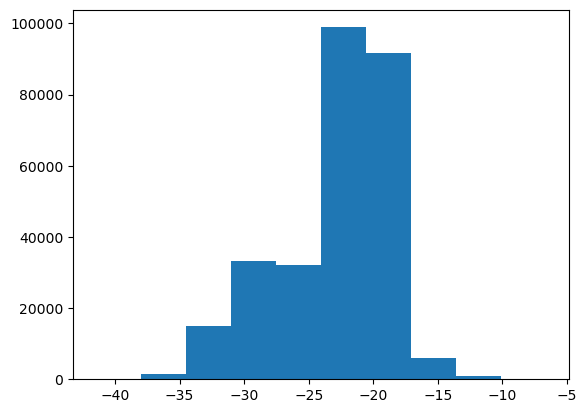

In [16]:
plt.figure()
plt.hist(da_VH_tot[0].values.flatten())
plt.show()

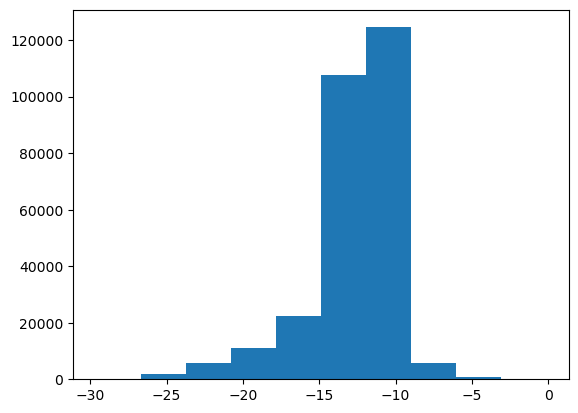

In [17]:
plt.figure()
plt.hist(da_VV_tot[0].values.flatten())
plt.show()

## Apply Median Filter

Apply a median filter to the data. This is often a standard step when dealing with SAR data, which is inherently noisy. 

In [18]:
for i in range(len(da_VV_tot)):
    da_VV_tot[i].values = signal.medfilt2d(da_VV_tot[i].values, kernel_size = median_size)

In [19]:
for i in range(len(da_VH_tot)):
    da_VH_tot[i].values = signal.medfilt2d(da_VH_tot[i].values, kernel_size = median_size)

***
# 3. Examine SAR Imagery

This section simply plots the raw SAR imagery. Data is assumed to be in decibels. 

In [20]:
def subplot_SAR_in_dB(da_tot, vmin=-25, vmax=-5): 

    num_modes = len(da_tot)

    # Create subplots
    n_cols = 2
    n_rows = int(np.ceil(num_modes/2))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12,n_rows*4))

    # Flatten axes array for easier indexing. 
    axes = axes.flatten()

    # Loop through and plot the modes. 
    for i in range(num_modes): 
        ax = axes[i]
        # myData_dB = 20 * np.log10(np.abs(da_tot[i].copy(deep=True).values + 1e-10))
        # ax.imshow(myData_dB, cmap='gray_r', vmin=vmin, vmax=vmax, interpolation=None)
        # ax.imshow(abs(da_tot[i].values), cmap='gray', vmin=vmin, vmax=vmax, interpolation=None)
        ax.imshow(da_tot[i].values, cmap='gray', vmin=vmin, vmax=vmax, interpolation=None)
        ax.set_title(f"Date: {da_tot[i].time.values.astype('datetime64[D]')}")

    # Turn off unused subplots
    for i in range(num_modes, len(axes)): 
        ax = axes[i]
        ax.set_axis_off()

    # Adjust layout
    plt.tight_layout()

    # Show plot. 
    plt.show()
    
    return

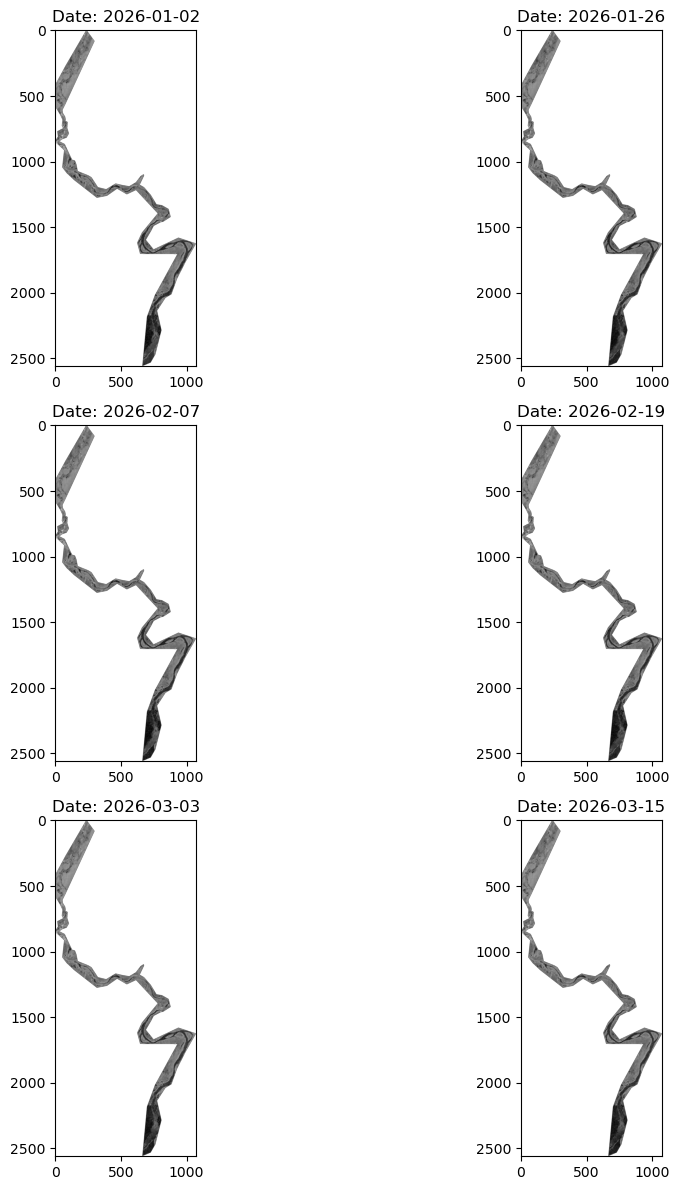

In [21]:
subplot_SAR_in_dB(da_VH_tot, vmin=-35, vmax=-5)

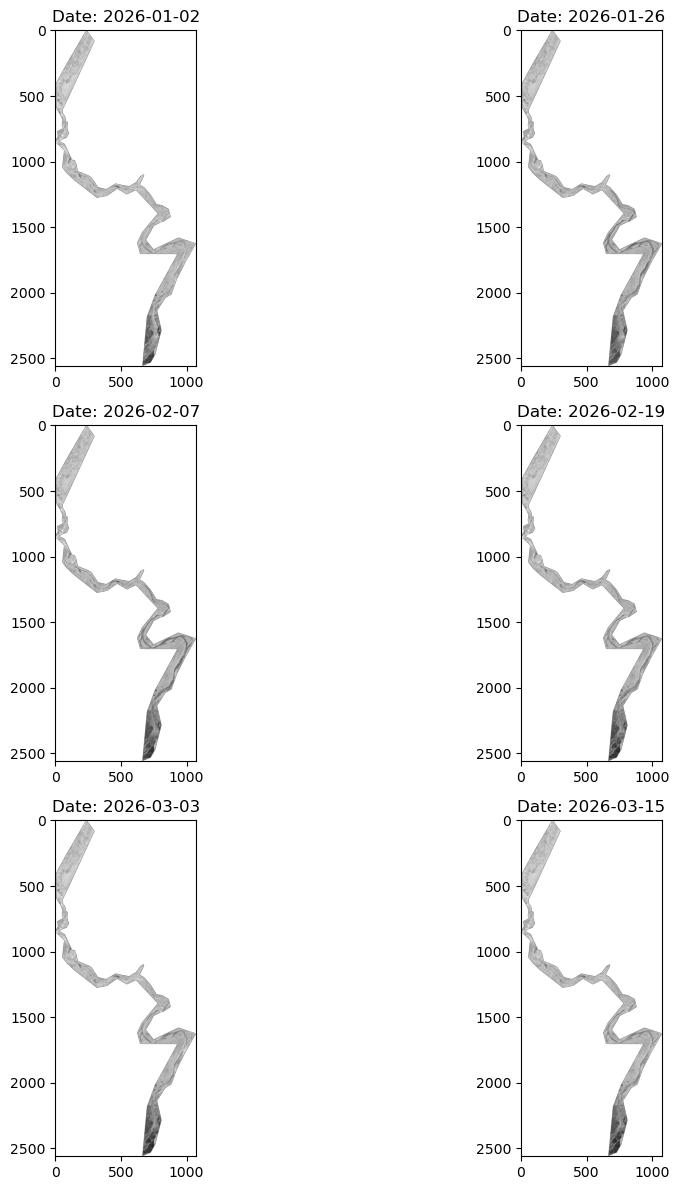

In [22]:
subplot_SAR_in_dB(da_VV_tot, vmin=-30, vmax=-5)

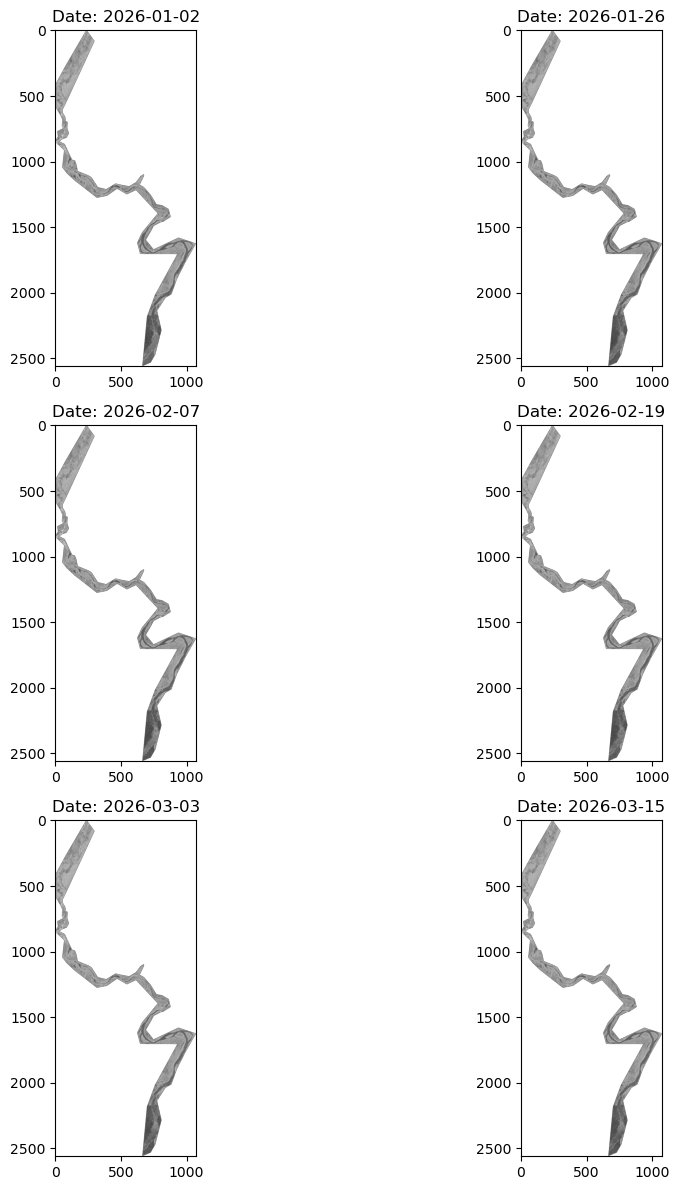

In [23]:
myMin = np.nanmin(da_VH_tot.values.flatten())
myMax = np.nanmax(da_VH_tot.values.flatten())

subplot_SAR_in_dB(da_VH_tot, 
                  vmin=myMin, 
                  vmax=myMax)

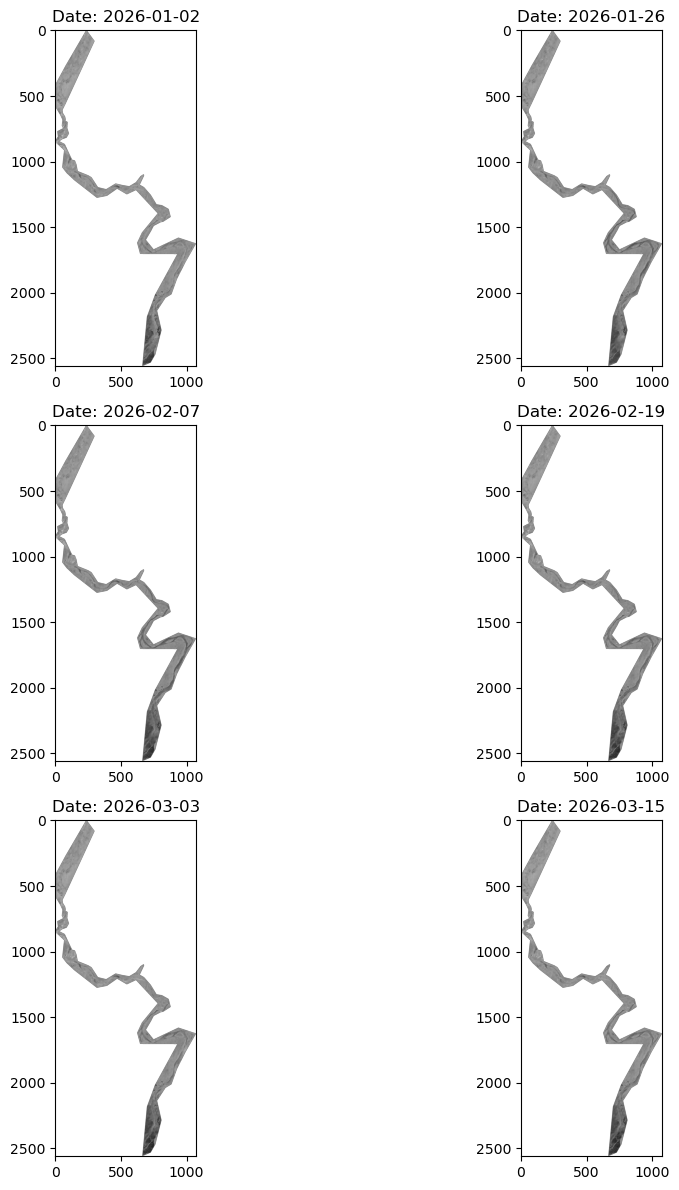

In [24]:
myMin = np.nanmin(da_VV_tot.values.flatten())
myMax = np.nanmax(da_VV_tot.values.flatten())

subplot_SAR_in_dB(da_VV_tot, 
                  vmin=myMin, 
                  vmax=myMax)

***
# 4. Calculate Change in dB levels

This section has two subsections. 
* 4.1 - In this section, the change in decibels is calculated.
* 4.2 - In this section, some statistics on the data are displayed. 

## 4.1 Do the calculation

In [25]:
# Initialize array to contain differences. 
t, y, x = da_VH_tot.shape[0]-1, da_VH_tot.shape[1], da_VH_tot.shape[2]
da_diffs_VH = np.zeros((t,y,x))
t, y, x = da_VV_tot.shape[0]-1, da_VV_tot.shape[1], da_VV_tot.shape[2]
da_diffs_VV = np.zeros((t,y,x))

In [26]:
def daDiffCalc(da_tot, w_s):
    # Function to get the difference between consecutive days in a data array. 
    # Note: This uses a median filter to stabilize values. 
    
    # da_tot - xarray data to get difference between consecutive days. 
    # w_s - window size to consider. 
    
    ts, ys, xs = da_tot.shape
    da_diffs = np.zeros((ts-1,ys,xs))
    temp = np.zeros((ys, xs))

    for i in range(ts-1): 
        temp = da_tot[i+1].values - da_tot[i].values
        da_diffs[i] = signal.medfilt2d(temp, kernel_size=w_s)

    return da_diffs

In [27]:
### --- Calculate difference between consecutive days --- ###

# Initialize container for differences. 
ts, ys, xs = da_VH_tot.shape
da_diffs_VH = np.zeros((len(window_sizes),ts-1,ys,xs))
da_diffs_VV = np.zeros((len(window_sizes),ts-1,ys,xs))

# Calculate differences. 
start_time = time.time()
for i, w_s in enumerate(window_sizes):
    # Run function to get differences. 
    da_diffs_VH[i] = daDiffCalc(da_VH_tot, w_s)
    da_diffs_VV[i] = daDiffCalc(da_VV_tot, w_s)

end_time = time.time()

print(f'It took {end_time-start_time:.2f} seconds to calculate decibel changes between consecutive days. ')

It took 0.71 seconds to calculate decibel changes between consecutive days. 


## 4.2 Difference Statistics

Plot some info about the differences calculated. 

The first plot shows the mean, mean +- standard deviation, and median for: all of the data, only the positive values, and only the negative values. This is useful for knowing where the bulk of the values (and therefore NOT overflow) is. 

The second plot shows the histograms of the differences for each date pair. This is useful for determining the threshold used in the next step. Overflow generally shows a full decibel drop in signal. 

In [28]:
# statistics (mean, median, standard deviation) plotting. 
def diffPlotStats(da_diffs, da_tot): 

    num_diffs = len(da_diffs)

    # Initialize containers for stats. 
    diffs_mean_all = np.zeros((num_diffs, 1))
    diffs_mean_pos = np.zeros((num_diffs, 1))
    diffs_mean_neg = np.zeros((num_diffs, 1))
    diffs_med_all  = np.zeros((num_diffs, 1))
    diffs_med_pos  = np.zeros((num_diffs, 1))
    diffs_med_neg  = np.zeros((num_diffs, 1))
    diffs_std_all  = np.zeros((num_diffs, 1))
    diffs_std_pos  = np.zeros((num_diffs, 1))
    diffs_std_neg  = np.zeros((num_diffs, 1))
    diffs_max      = np.zeros((num_diffs, 1))
    diffs_min      = np.zeros((num_diffs, 1))
    datePairs      = [None] * num_diffs

    # Loop through differences to get stats info. 
    for i in range(num_diffs): 
        diffs_mean_all[i] = np.nanmean(da_diffs[i])
        diffs_mean_pos[i] = np.nanmean(da_diffs[i][da_diffs[i]>0.0])
        diffs_mean_neg[i] = np.nanmean(da_diffs[i][da_diffs[i]<0.0])
        
        diffs_med_all[i]  = np.nanmedian(da_diffs[i])
        diffs_med_pos[i]  = np.nanmedian(da_diffs[i][da_diffs[i]>0.0])
        diffs_med_neg[i]  = np.nanmedian(da_diffs[i][da_diffs[i]<0.0])
        
        diffs_std_all[i]  = np.nanstd(da_diffs[i])
        diffs_std_pos[i]  = np.nanstd(da_diffs[i][da_diffs[i]>0.0])
        diffs_std_neg[i]  = np.nanstd(da_diffs[i][da_diffs[i]<0.0])

        diffs_max[i]      = np.nanmax(da_diffs[i])
        diffs_min[i]      = np.nanmin(da_diffs[i])

        # For x axis ticks
        datePairs[i]      = f"{da_tot[i].time.values.astype('datetime64[D]')}\n&\n{da_tot[i+1].time.values.astype('datetime64[D]')}"

    
    # Create figures
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(9,12))

        
    # Plot 'all's
    dummy = np.arange(num_diffs)
    axes[0].plot(datePairs, diffs_mean_all, color='blue')
    axes[0].plot(datePairs, diffs_med_all, color='green')
    axes[0].plot(datePairs, diffs_mean_all+diffs_std_all, color='blue', marker='v', linestyle='None')
    axes[0].plot(datePairs, diffs_mean_all-diffs_std_all, color='blue', marker='^', linestyle='None')
    axes[1].plot(datePairs, diffs_mean_pos, color='blue')
    axes[1].plot(datePairs, diffs_med_pos, color='green')
    axes[1].plot(datePairs, diffs_mean_pos+diffs_std_pos, color='blue', marker='v', linestyle='None')
    axes[1].plot(datePairs, diffs_mean_pos-diffs_std_pos, color='blue', marker='^', linestyle='None')
    axes[2].plot(datePairs, diffs_mean_neg, color='blue')
    axes[2].plot(datePairs, diffs_med_neg, color='green')
    axes[2].plot(datePairs, diffs_mean_neg+diffs_std_neg, color='blue', marker='v', linestyle='None')
    axes[2].plot(datePairs, diffs_mean_neg-diffs_std_neg, color='blue', marker='^', linestyle='None')

    axes[0].grid()
    axes[1].grid()
    axes[2].grid()

    # axes[0].set_xticks(ticks=datePairs, rotation=45)
    axes[0].tick_params(axis='x', labelrotation=45)
    axes[1].tick_params(axis='x', labelrotation=45)
    axes[2].tick_params(axis='x', labelrotation=45)
    
    # Set titles. 
    fig.suptitle("Statistics of Differences\nBlue Line - Mean\nBlue Triangles - Mean +- Standard Deviation\nGreen Line - Median")
    axes[0].set_title("All values")
    axes[1].set_title("Positive values only")
    axes[2].set_title("Negative values only")
    
    # Adjust layout
    plt.tight_layout()

    # Show plot. 
    plt.show()
    
    return

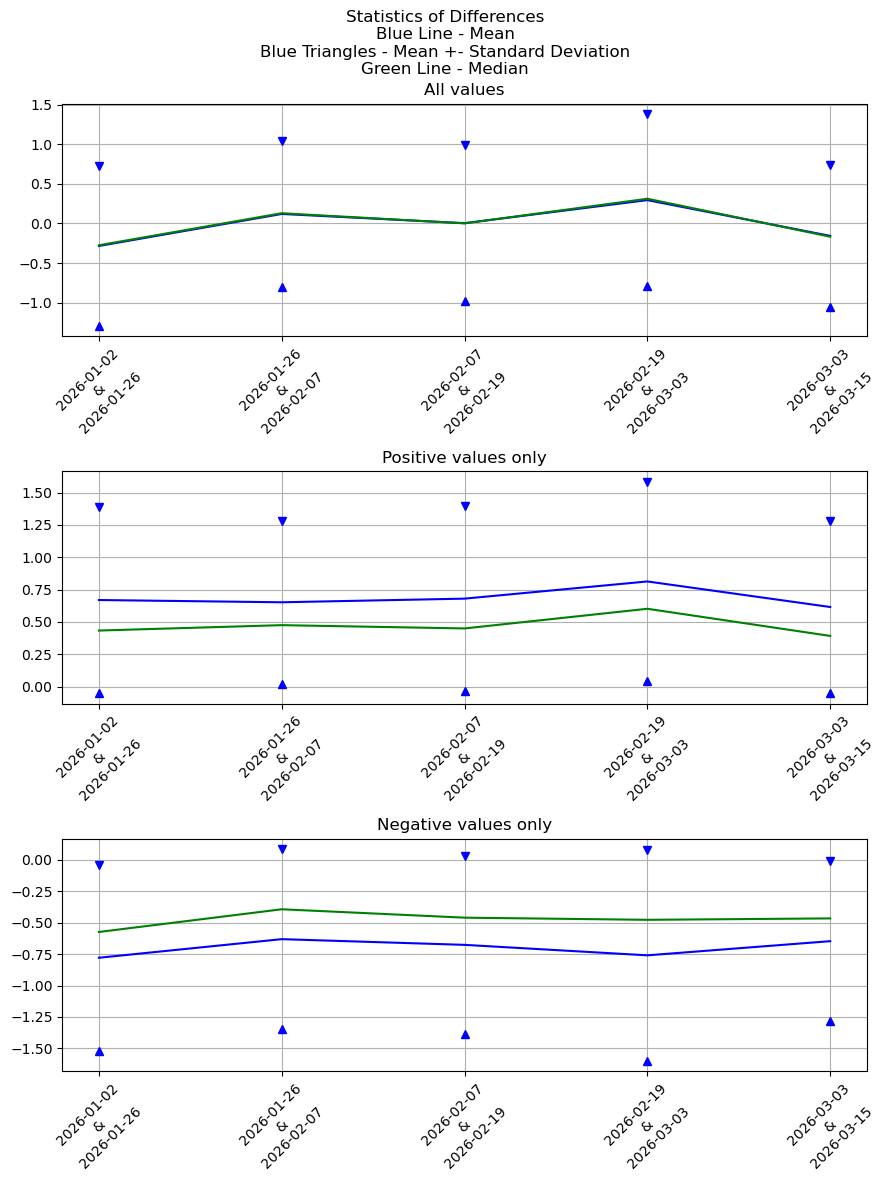

In [29]:
diffPlotStats(da_diffs_VH[0], da_VH_tot)

/tmp/ipykernel_318/4276938397.py:23: RuntimeWarning: Mean of empty slice
  diffs_mean_pos[i] = np.nanmean(da_diffs[i][da_diffs[i]>0.0])
/opt/conda/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/conda/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


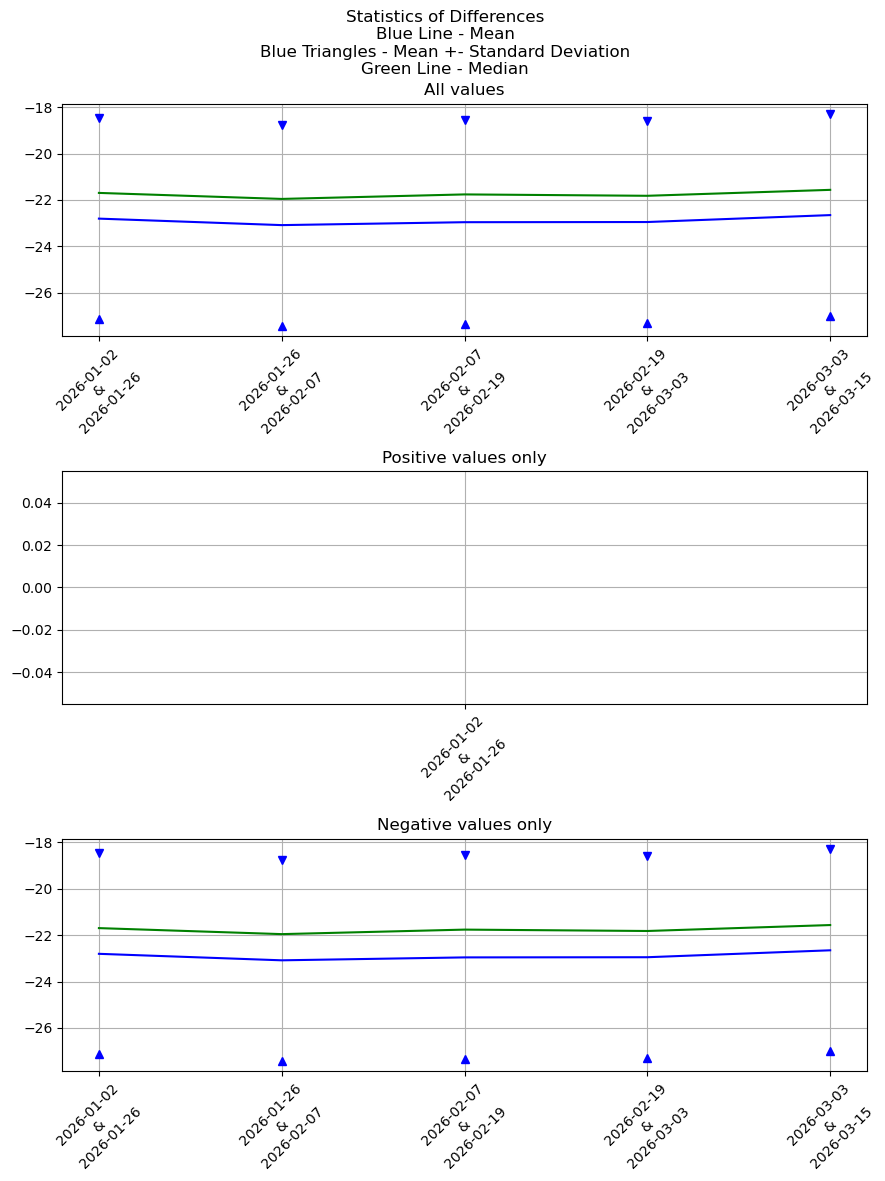

In [30]:
diffPlotStats(da_VH_tot[:-1].values, da_VH_tot)

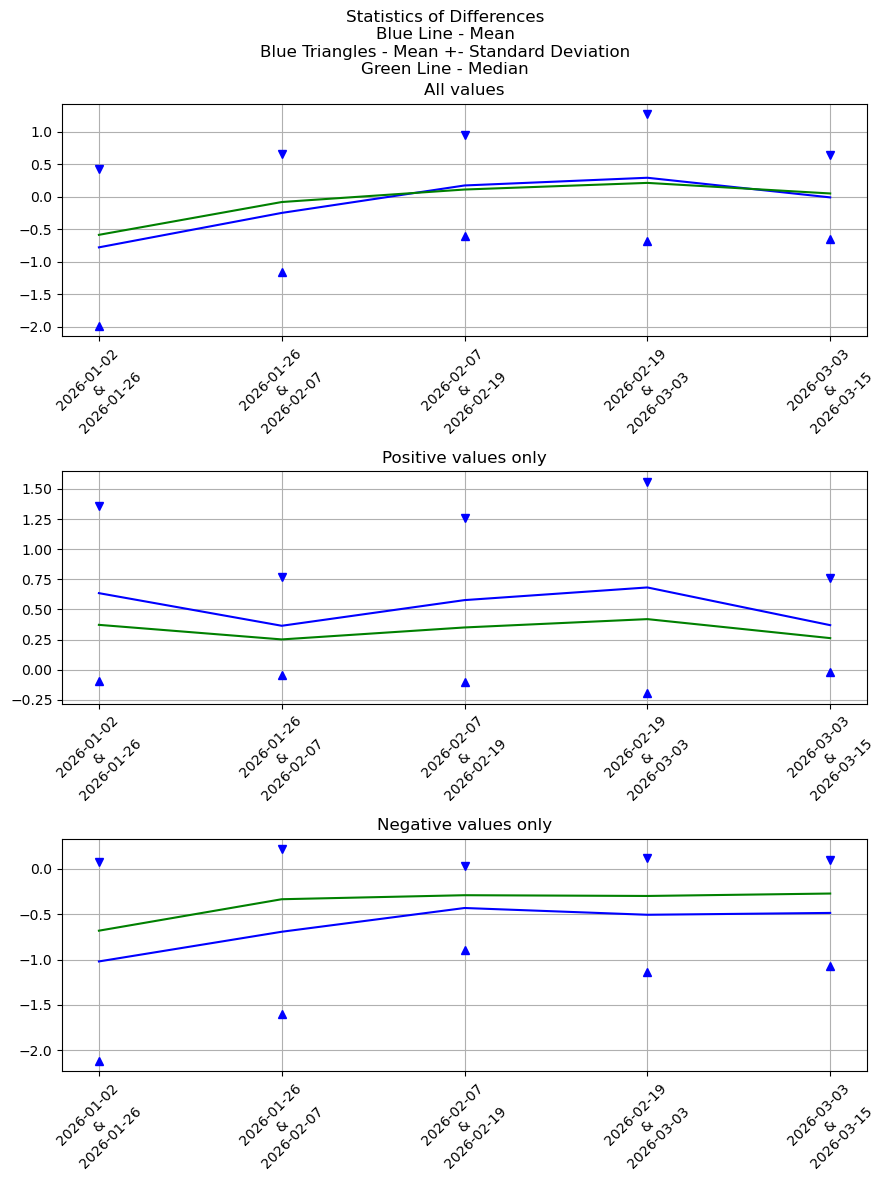

In [31]:
diffPlotStats(da_diffs_VV[0], da_VV_tot)

/tmp/ipykernel_318/4276938397.py:23: RuntimeWarning: Mean of empty slice
  diffs_mean_pos[i] = np.nanmean(da_diffs[i][da_diffs[i]>0.0])


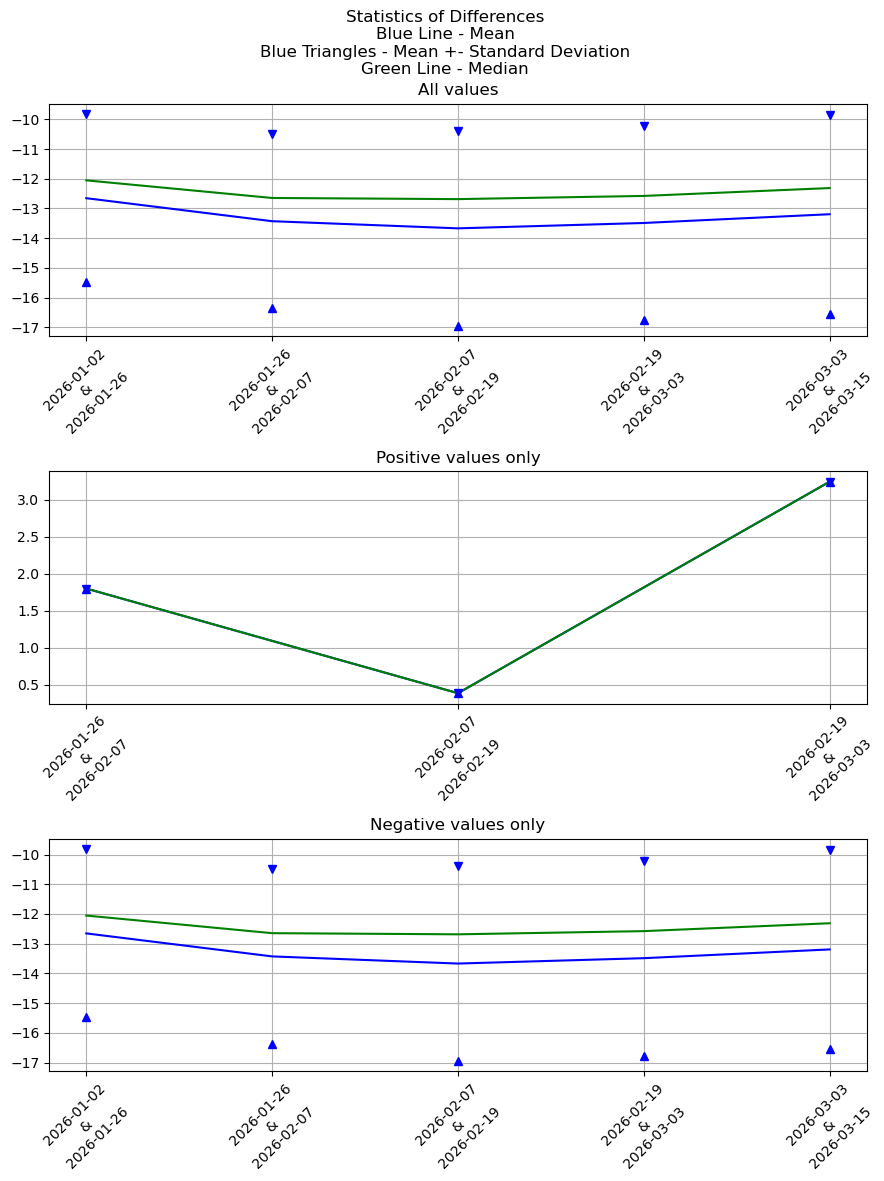

In [32]:
diffPlotStats(da_VV_tot[:-1].values, da_VV_tot)

In [33]:
# Histogram plotting. 
def diffPlotHistograms(da_diffs, da_tot, num_bins=30): 

    num_plots = len(da_diffs)

    # Create subplots
    n_cols = 2
    n_rows = int(np.ceil(num_plots/2))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12,n_rows*4))

    # Flatten axes array for easier indexing. 
    axes = axes.flatten()

    myMax = np.nanmax(da_diffs)
    myMin = np.nanmin(da_diffs)

    # Loop through and plot the modes. 
    for i in range(num_plots): 
        ax = axes[i]
        ax.hist(da_diffs[i].flatten(), density=True, log=True, bins=num_bins, range=(myMin, myMax))
        ax.set_title(f"Date Pairs: {da_tot[i].time.values.astype('datetime64[D]')} & {da_tot[i+1].time.values.astype('datetime64[D]')}")
        ax.set_ylabel('Probability')
        ax.set_xlabel('Values')
        ax.grid()

    # Turn off unused subplots
    for i in range(num_plots, len(axes)): 
        ax = axes[i]
        ax.set_axis_off()

    fig.suptitle("Histograms of values")

    # Adjust layout
    plt.tight_layout()

    # Show plot. 
    plt.show()
    
    return

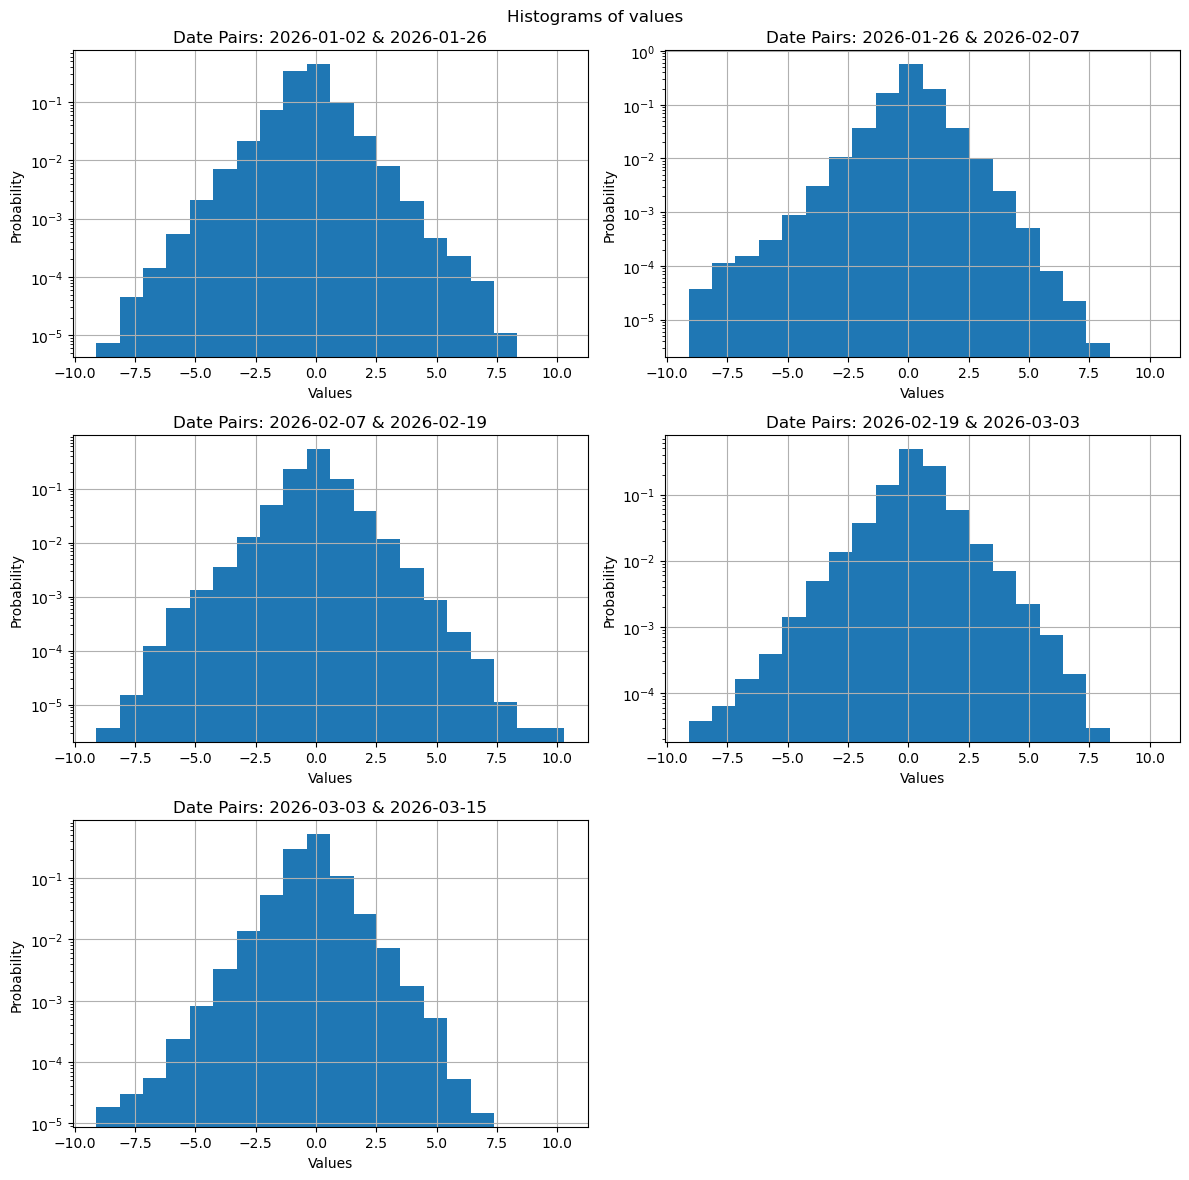

In [34]:
diffPlotHistograms(da_diffs_VH[0], da_VH_tot, num_bins = 20)

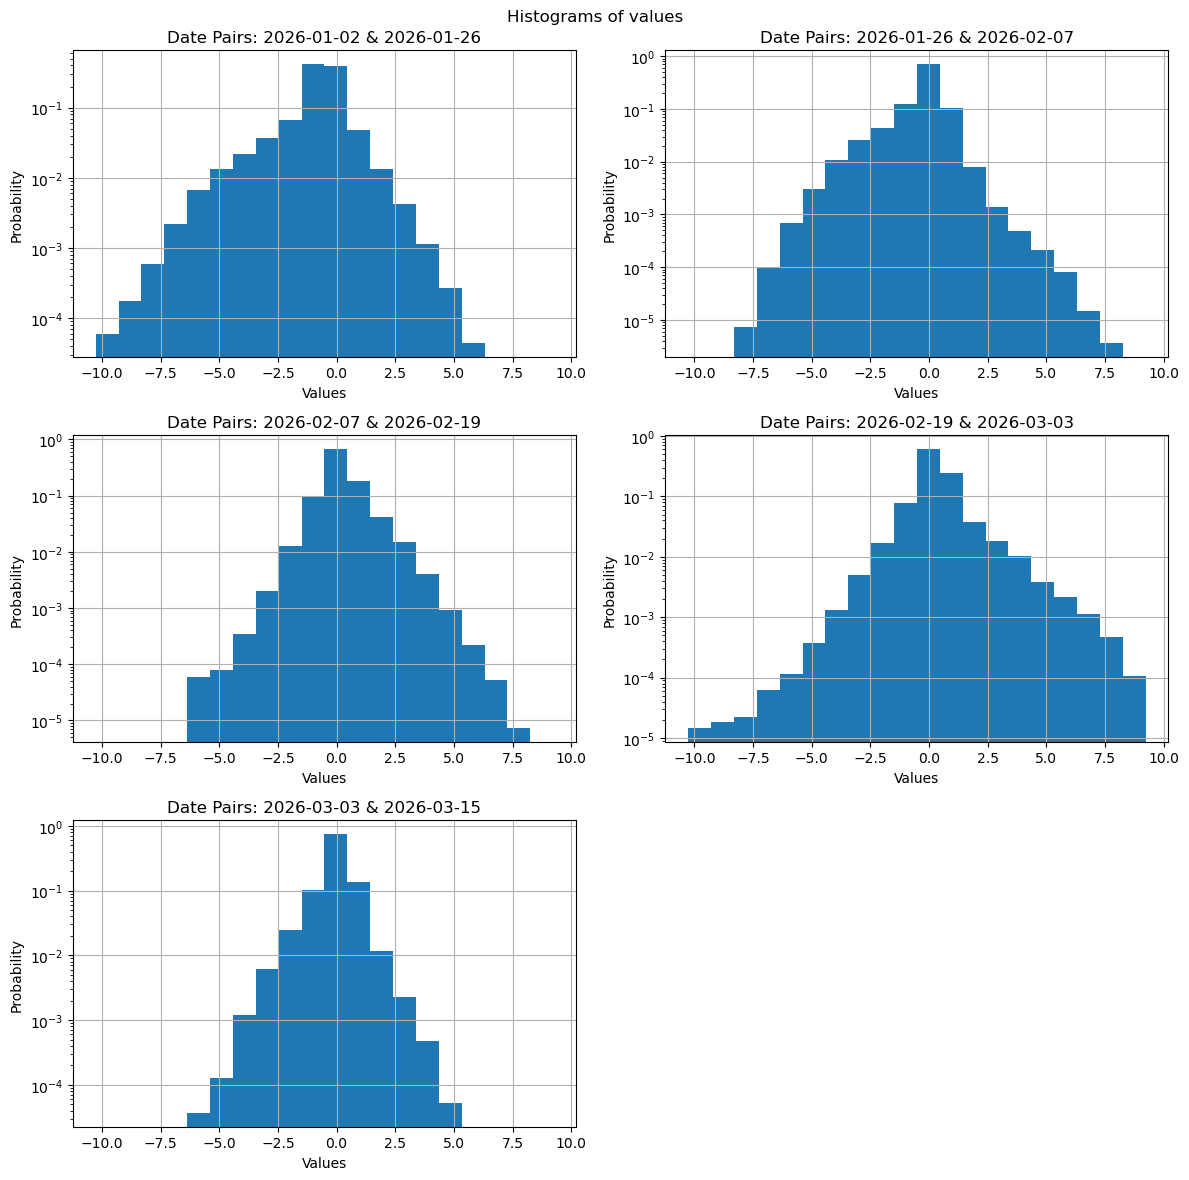

In [35]:
diffPlotHistograms(da_diffs_VV[0], da_VV_tot, num_bins = 20)

# 5. Find Overflow

Overflow seems to be characterized by a small drop in backscatter following consistent increases. The below code finds possible overflow eventws by searching for positive changes in backscatter (i.e., the backscatter is increasing) followed by a negative change in backscatter (i.e., the backscatter decreases). 

There are three sections:
* 5.1 - Potential Overflow Identification
  * This section finds potential overflow on a pixel by pixel basis.
* 5.2 - Group Pixels
  * This section groups those individual pixels based on two criteria: proximity and time. We group the identified pixels that touch on the same date pair.
* 5.3 - Cull Data Groups
  * This section looks at the mean and median backscatter changes of the grouped pixels and removes those that no longer meet the minimum +/- change expected. 
* 5.4 - Selected Example of Possible Overflow
  * Example plot of the change in backscatter for a possible overflow grouping. 

## 5.1 Potential Overflow Identification

The below code finds which individual pixels meet the criteria for possible overflow. 

In [59]:
def findSastrugiIndices(diffs_VV, diffs_VH, pos = 0.5, neg = -0.5, start_ind = 0, stop_ind = -1):
    # Function to find indices of overflow. 
    # This method is predicated on sastrugis having an increase in VV and decrease in VH. 
    # Note: This automatically filters by time. 

    # Input variables:
    # diffs_VV - array containing VV differences. 
    # diffs_VH - array containing VH differences. 
    # pos - minimum value for positives. 
    # neg - minimum value for negatives. 

    # Output variables: 
    # myIndices - list of all indices for possible overflow. 
    # idx0 - x indices of myIndices as a list; this can be easier to use than myIndices. 
    # idx1 - y indices of myIndices as a list. 

    # initialize some containers
    list_pos = []
    list_neg = []

    if stop_ind == -1:
        stop_ind = len(diffs_VV)-1
    if start_ind < 0:
        print(f"start_ind less than zero: start_ind = {start_ind}. \nConverting to appropriate index...")
        start_ind = stop_ind - abs(start_ind) + 1
        print(f"start_ind after conversion: {start_ind}")

    # Loop through all of the difference pairs. 
    for i in range(start_ind, stop_ind):
        # get temporary list of positive "nows" and negative "tomorrows"
        temp_pos = np.where(diffs_VV[i] > pos)
        temp_neg = np.where(diffs_VH[i] < neg)

        # Put positives and their date indices into a list. 
        for j in range(len(temp_pos[0])):
            list_pos.append([temp_pos[0][j], temp_pos[1][j], i])

        # Put negatives and their date indices into a list. 
        for j in range(len(temp_neg[0])):
            list_neg.append([temp_neg[0][j], temp_neg[1][j], i])

    # Put the indices into a single list if they have the same location and time index. 
    myIndices = [list(item) for item in set(map(tuple, list_pos)) & set(map(tuple, list_neg))]
    
    idx0 = [sublist[0] for sublist in myIndices]
    idx1 = [sublist[1] for sublist in myIndices]
    
    return myIndices, idx0, idx1

### <span style="color:red"><b>USER INPUT MODIFICATION CAN BE MADE HERE!!!</b></span>

min_pos - smallest positive change prior to the drop in backscatter. <br>
min_neg - smallest negative change to backscatter. 

start_ind - starting index at which to look for overflow. <br>
stop_ind  - last index for which to look for overflow. Setting this to -1 will go to the last index. 

To modify the user input, delete the '#' symbol and change the value to desired setting. 

In [54]:
# # set delta_dB thresholds. 
# min_pos = 0.1
# min_neg = [-3.0, -2.0, -1.0]
# # make sure 'min_neg' is a list
# if not isinstance(min_neg, list):
#     min_neg = [min_neg]
#     print(f"min_neg converted to list")
# # Make sure minimum values are in order from lowest (most stringent) to highest (least stringent). 
# min_neg.sort()

# Set start and stop indices. This is useful if you are dealing with e.g., several months of data that includes time that can't possibly have overflow. 
start_ind = 0
stop_ind = -1

print(f"start_ind: {start_ind}\nstop_ind:  {stop_ind}")
print(f"start date: {da_VV_tot[start_ind].time.values.astype('datetime64[D]')}\nend date:   {da_VV_tot[stop_ind].time.values.astype('datetime64[D]')}")

start_ind: 0
stop_ind:  -1
start date: 2026-01-02
end date:   2026-03-15


In [38]:
def removeDups(myList, myListWithDups):
    # Function to remove duplicate lists from a list of lists found in a different list of lists. 
    # myListWithDups - list of lists with duplicate lists to be removed. 
    # myList - list of duplicates to be removed from myListWithDups. 

    # Convert lists in myList to a set of tuples for efficient lookup. 
    set_myList = set(tuple(sub) for sub in myList)

    # Use list comprehension to keep items in myListWithDups that are not in set_myList
    myListWithoutDups = [sub for sub in myListWithDups if tuple(sub) not in set_myList]
    
    return myListWithoutDups

In [60]:
myIndices_sastrugi = []

# Get list of indices for all probabilities (i.e., thresholds). 
for pair in zip(delta_VV, delta_VH):
    min_pos = pair[0]
    min_neg = pair[1]
    print(min_pos, min_neg)
    myIndices_temp, _, _ = findSastrugiIndices(da_diffs_VV[0], da_diffs_VH[0], pos=min_pos, neg=neg, start_ind=start_ind, stop_ind=stop_ind)
    myIndices_sastrugi.append(myIndices_temp)

# Remove duplicates from lower probability lists. 
if len(delta_VV) > 1:
    for i in range(len(delta_VV)-1):
        myIndices_sastrugi[i+1] = removeDups(myIndices_sastrugi[i], myIndices_sastrugi[i+1])
        
for i in range(len(myIndices_sastrugi)):
    print(f"For delta_VV & delta_VH = {delta_VV[i]} & {delta_VH[i]}, there are {len(myIndices_sastrugi[i])} possible sastrugi pixels identified.")


1.0 -1.0
For delta_VV & delta_VH = 1.0 & -1.0, there are 1355 possible sastrugi pixels identified.


In [62]:
### Create plotting function for possible overflow! ###
def plotSastrugiProbabilities(da, myIndices, cmap = 'viridis'):
    # Function to plot probable overflow locations. 
    # da - single SAR image. 
    # myIndices - list of lists of lists; this contains the indices for each identified possible overflow point for different

    # plot SAR image background. 
    fig = plt.figure(figsize=(12,9))
    plt.imshow(da, cmap='gray', interpolation='None')

    # Create color list based on number of myIndices lists. 
    n_colors = len(myIndices)
    color = cm.rainbow(np.linspace(0, 1, n_colors))

    # Loop through each list of myIndices. 
    for i in range(len(myIndices)-1, -1, -1):
        # get necessary indices.     
        idx0 = [sublist[0] for sublist in myIndices[i]]
        idx1 = [sublist[1] for sublist in myIndices[i]]        

        plt.plot(idx1, idx0, color=color[i], marker='.', markersize=1, linestyle='None', alpha=0.5)

    # Add grid lines. 
    plt.grid()
    plt.show()
    
    return

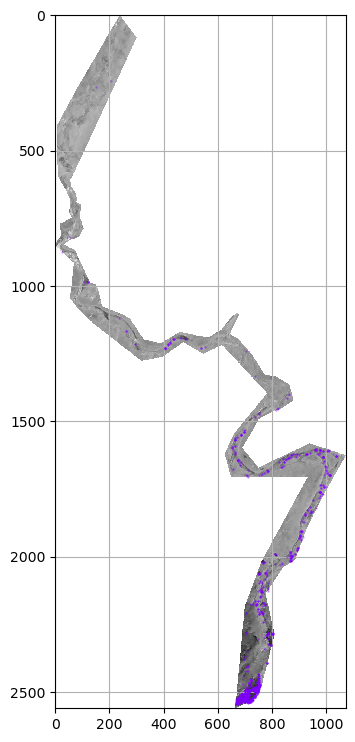

In [63]:
plotSastrugiProbabilities(da_VV_tot[0], myIndices_sastrugi)

## 5.2 Group Pixels

The below code finds the pixels identified as potential overflow that touch each other and groups them. Otherwise, we can end up with a list of thousands. 

In [83]:
def groupAllByContact(myIndices, threshPair, da_tot, min_pixels=4, max_pixels=float('inf')):
    # Function to group overflow locations into a dictionary for easy calling/use. 

    # Input variables: 
    # myIndices - list of indices that have been flagged as possible overflow. If len(min_neg) > 1, this will be a list of lists. 
    # min_neg - list of negative thresholds used to determine if a pixel is considered overflow. This can be a single number. 
    # da_tot - xarray containing the original SAR image data. 
    # min_pixels - minimum number of pixels a group needs in order to be retained. 

    # Output variables: 
    # myDates - list of dates as strings. 
    # myDatas - raw and statistical data as a dictionary. 

    # Initialize dictionary container for the data. 
    myDatas = {}

    for i in range(len(threshPair)): 
        min_pos = threshPair[i][0]
        min_neg = threshPair[i][1]
        print(f'  Starting grouping for thresholds_pos/neg ={min_pos} & {min_neg} with {len(myIndices[i])} pixels.')
        start_time = time.time()
        # Get indices from myIndices
        idx0 = [sublist[0] for sublist in myIndices[i]]
        idx1 = [sublist[1] for sublist in myIndices[i]]

        # Create a binary mask of overflow pixels
        ts, ys, xs = da_tot.shape # get the shape needed. 
        print(f"da_tot.shape = {da_tot.shape}")
        print(f"max(idx0)&max(idx1) = {np.max(idx0)}, {np.max(idx1)}")
        sastrugi_ungrouped = np.zeros((ys,xs)) # initialize as an array of zeros. 
        sastrugi_ungrouped[idx0, idx1] = 1 # add 1's for indices that have been identified as possible overflow. 

        # Call code to group each set of pixels. 
        myDatas[f'thresh={min_pos}&{min_neg}'], myDates = groupOneByContact(sastrugi_ungrouped, da_tot, min_pixels=min_pixels, max_pixels=max_pixels)

        end_time = time.time()
        print(f'  It took {end_time-start_time:.2f} seconds to group the pixels for thresholds_pos/neg={min_pos} & {min_neg}. ')
        
    
    return myDatas, myDates

def groupOneByContact(possible_sastrugi, da_tot, min_pixels=4, max_pixels=float('inf')):
    # Function to group overflow locations into a dictionary for easy calling/use. 

    # Input variables: 
    # possible_sastrugi - the mask of potential sastrugi (0 where no sastrugi; 1 where possibly detected)
    # da_tot - xarray containing the original SAR image data. 
    # min_pixels - minimum number of pixels a group needs in order to be retained. 

    # Output variables: 
    # myDates - list of dates as strings. 
    # myData  - raw and statistical data as a dictionary. 

    
    # Group locations by pixels that touch. 
    # connectivity = 1 for only up/down connections. 
    # connectivity = 2 for up/down and diagonal connections. 
    labeled_image = label(possible_sastrugi, connectivity=2)

    # Remove groups of pixels that are smaller than 'min_pixels.' 
    for i in range(1,np.max(labeled_image)+1): 
        pixelIndices = np.where(labeled_image == i)
        pixelCount = len(pixelIndices[0])
        if (pixelCount < min_pixels) or (pixelCount > max_pixels): 
            labeled_image[np.where(labeled_image == i)] = 0

    # Put raw data into dictionary for each grouping. 
    # Get unique entries and their counts. Used for organizing later. 
    unique_vals, counts = np.unique(labeled_image, return_counts=True)    
    # initialize container for backscatter values. 
    myData = {}    
    myDates = []
    for val in unique_vals[1:]: # skipping 0 since that will just be non-overflow. 
        myIndex = np.where(labeled_image == val)
        ts = len(da_tot)
        ps = len(myIndex[0])
        myDates = da_tot[:].time.values.astype('datetime64[D]')
        myValues = np.zeros(( ts, ps))
        # Add values to dictionary. 
        myD = {}
        for i in range(ps):
            myValues[:, i] = da_tot[:, myIndex[0][i], myIndex[1][i]].values
        myD['raw'] = myValues
        myData[f"{val}"] = myD
        # Add indices of location to dictionary. 
        myIndices = []
        for i in range(len(myIndex[0])):
            myIndices.append([myIndex[0][i], myIndex[1][i]])
        myData[f"{val}"]['indices'] = myIndices

    # Get statistics into 'myDatas.' 
    for key in myData:
        # Initialize containers for mean, median, and std. 
        myMeans   = np.zeros((1,0))
        myMedians = np.zeros((1,0))
        myStds    = np.zeros((1,0))
        # Get stats for each key. 
        for i in range(len(myData[key]['raw'])):
            myMean =  np.nanmean(myData[key]['raw'][i])
            myMeans = np.append(myMeans,myMean)
    
            myMedian =  np.nanmedian(myData[key]['raw'][i])
            myMedians = np.append(myMedians,myMedian)
    
            myStd =  np.nanstd(myData[key]['raw'][i])
            myStds = np.append(myStds, myStd)
    
        # Put stats in dictionary. 
        myData[key]['mean']   = myMeans
        myData[key]['median'] = myMedians
        myData[key]['std']    = myStds
    
    return myData, myDates

### <span style="color:red"><b>USER MODIFICATION CAN BE MADE HERE!!!</b></span>

Please select the minimum number of touching pixels (min_pixels) for your overflow region. Note that the maximum may also be selected. 

In [65]:
# # Typical overflow event are approximately 15 S1 pixels in size. 
# min_pixels = 4
# max_pixels = float('inf')

In [84]:
start_time = time.time()
threshPairs = [list(pair) for pair in zip(delta_VV, delta_VH)]

# Group sastrugi data. 
print('Starting grouping...')
myDatas_sastrugi_VH, myDates = groupAllByContact(myIndices_sastrugi,
                                        threshPairs, 
                                        da_VH_tot, 
                                        min_pixels=min_pixels,
                                        max_pixels=max_pixels)

myDatas_sastrugi_VV, myDates = groupAllByContact(myIndices_sastrugi,
                                        threshPairs, 
                                        da_VV_tot, 
                                        min_pixels=min_pixels,
                                        max_pixels=max_pixels)

end_time = time.time()
print(f'It took {end_time-start_time:.2f} seconds to group the pixels. ')

Starting grouping...
  Starting grouping for thresholds_pos/neg =1.0 & -1.0 with 1355 pixels.
da_tot.shape = (6, 2560, 1074)
max(idx0)&max(idx1) = 2543, 1036
  It took 4.18 seconds to group the pixels for thresholds_pos/neg=1.0 & -1.0. 
  Starting grouping for thresholds_pos/neg =1.0 & -1.0 with 1355 pixels.
da_tot.shape = (6, 2560, 1074)
max(idx0)&max(idx1) = 2543, 1036
  It took 4.78 seconds to group the pixels for thresholds_pos/neg=1.0 & -1.0. 
It took 8.96 seconds to group the pixels. 


In [85]:
for thresh in myDatas_sastrugi_VV:
    print(thresh)
    print(f"  Number of grouped locations {len(myDatas_sastrugi_VV[thresh])}")
    for key in myDatas_sastrugi_VV[thresh]:
        print(f"    Key: {key},  # of indices: {len(myDatas_sastrugi_VV[thresh][key]['indices'])}")

thresh=1.0&-1.0
  Number of grouped locations 83
    Key: 14,  # of indices: 4
    Key: 16,  # of indices: 5
    Key: 19,  # of indices: 7
    Key: 29,  # of indices: 5
    Key: 30,  # of indices: 7
    Key: 33,  # of indices: 5
    Key: 35,  # of indices: 4
    Key: 39,  # of indices: 7
    Key: 40,  # of indices: 4
    Key: 47,  # of indices: 5
    Key: 55,  # of indices: 4
    Key: 58,  # of indices: 6
    Key: 61,  # of indices: 9
    Key: 62,  # of indices: 7
    Key: 66,  # of indices: 6
    Key: 72,  # of indices: 4
    Key: 77,  # of indices: 4
    Key: 91,  # of indices: 9
    Key: 99,  # of indices: 4
    Key: 102,  # of indices: 12
    Key: 110,  # of indices: 6
    Key: 113,  # of indices: 6
    Key: 118,  # of indices: 6
    Key: 119,  # of indices: 9
    Key: 121,  # of indices: 4
    Key: 123,  # of indices: 4
    Key: 126,  # of indices: 4
    Key: 127,  # of indices: 5
    Key: 128,  # of indices: 5
    Key: 133,  # of indices: 9
    Key: 135,  # of indices: 5
    Key:

In [86]:
# Plot data for user to look through graphs and identify likely days/locations with overflow. 

def plotdBForEachLocation(myDatas, myDates, ymin=-24.0, ymax=-5.0, start_ind=0, stop_ind=-1):

    # loop through each key in 'myDatas' dictionary. 
    # Note: The keys should correspond to the unique values of possible overflow groupings. 

    if len(myDatas) == 0:
        print("No data to plot.") 
    else: 
        ncols = 2
        nrows = int(np.ceil(len(myDatas)/2))
    
        n_max = 20
        if nrows > n_max:
            print(f"Too many individual indices.\nPlotting only those from {start_ind} to {start_ind+20}.")
            print("To plot a different range of individual points, set 'start_ind' and 'stop_ind'.")
            nrows = int(n_max / 2)
            stop_ind = start_ind + n_max - 1
        else: 
            stop_ind = len(myDatas)
        
        fig_find, axes_find = plt.subplots(nrows=nrows, ncols=ncols, figsize=(9,nrows*4))
        
        axes_find = axes_find.flatten()
        
        for i, key in enumerate(myDatas): 
            if i >= start_ind and i <= stop_ind:
                ax = axes_find[i]
                ax.plot(myDates, myDatas[key]['mean'], color='blue')
                ax.plot(myDates, myDatas[key]['mean']+myDatas[key]['std'], color='blue', marker='v', linestyle='None')
                ax.plot(myDates, myDatas[key]['mean']-myDatas[key]['std'], color='blue', marker='^', linestyle='None')
                ax.plot(myDates, myDatas[key]['median'], color='green')
                ax.grid()    
                ax.set_xticks(myDates, myDates, rotation=45)
                ax.set_title(f"Location Number: {key}")
                ax.set_ylim(ymin, ymax)
    
        for j in range(i+1, len(axes_find)):
            ax = axes_find[j]
            ax.set_axis_off()
        
        plt.tight_layout()
        plt.show()

    return

### <span style="color:red"><b>NOTE: </b></span>

The graphs below will be used to select which of the possible overflow locations to examine in further detail. Typically, overflow is preceded by slowly increasing backscatter through time with a minor spike in the data before a small (but noticeable) drop in backscatter. 

Typically, locations likely to have overflow have background backscatter values greater than -22 dB. 

thresh=1.0&-1.0
Too many individual indices.
Plotting only those from 0 to 20.
To plot a different range of individual points, set 'start_ind' and 'stop_ind'.


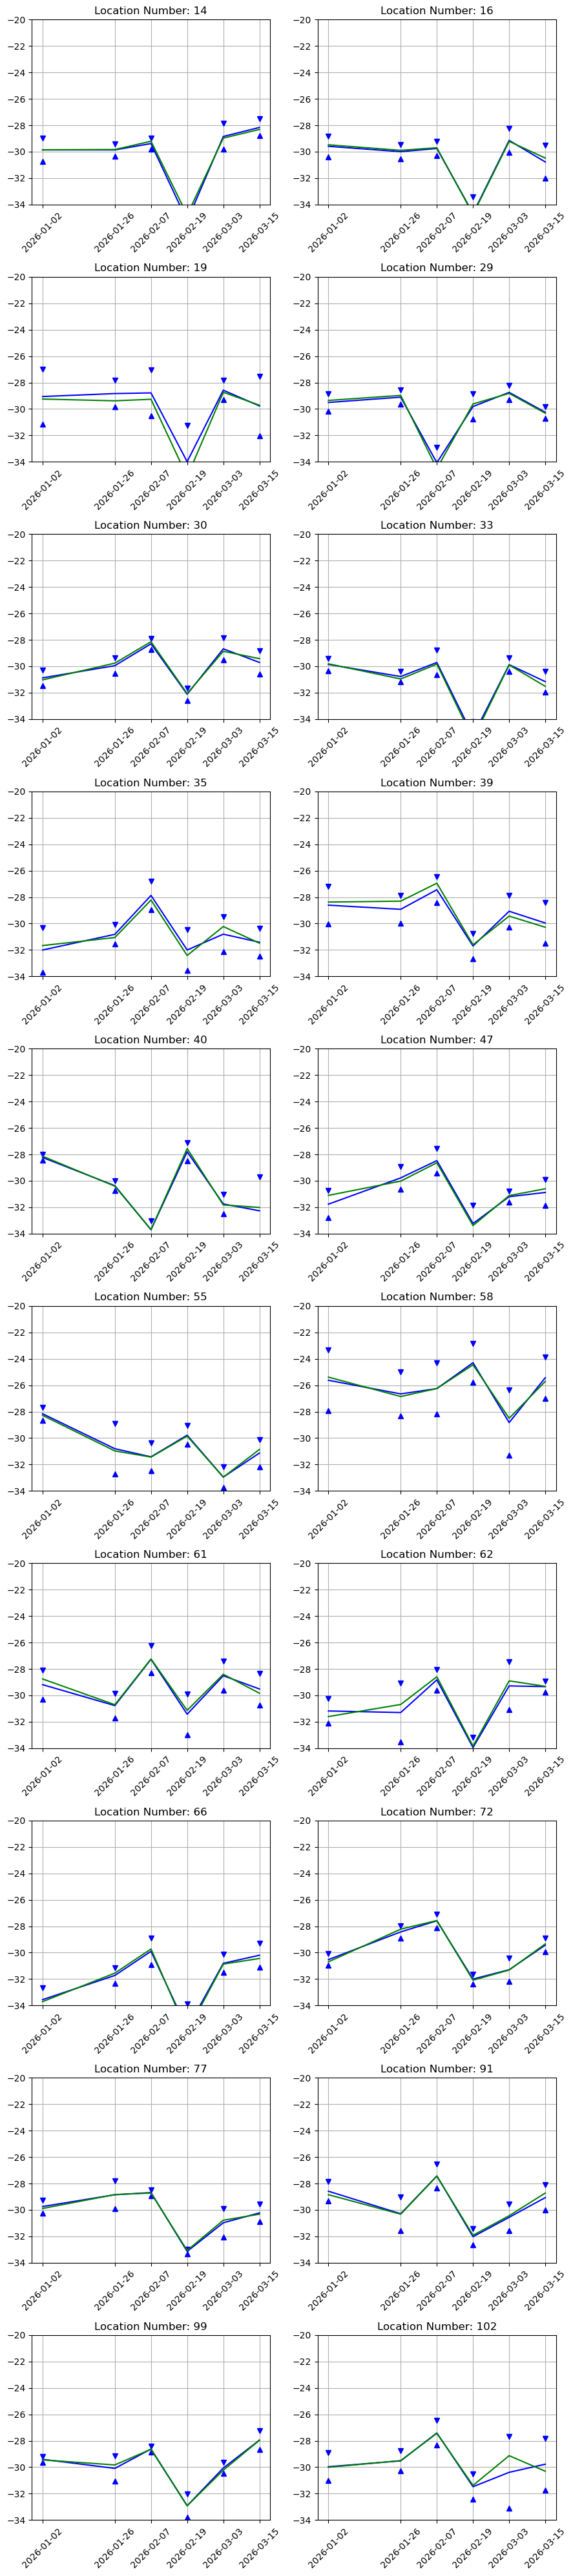

In [88]:
for thresh in myDatas_sastrugi_VH:
    print(thresh)
    plotdBForEachLocation(myDatas_sastrugi_VH[thresh], myDates, ymin = -34., ymax = -20.)

thresh=1.0&-1.0
Too many individual indices.
Plotting only those from 0 to 20.
To plot a different range of individual points, set 'start_ind' and 'stop_ind'.


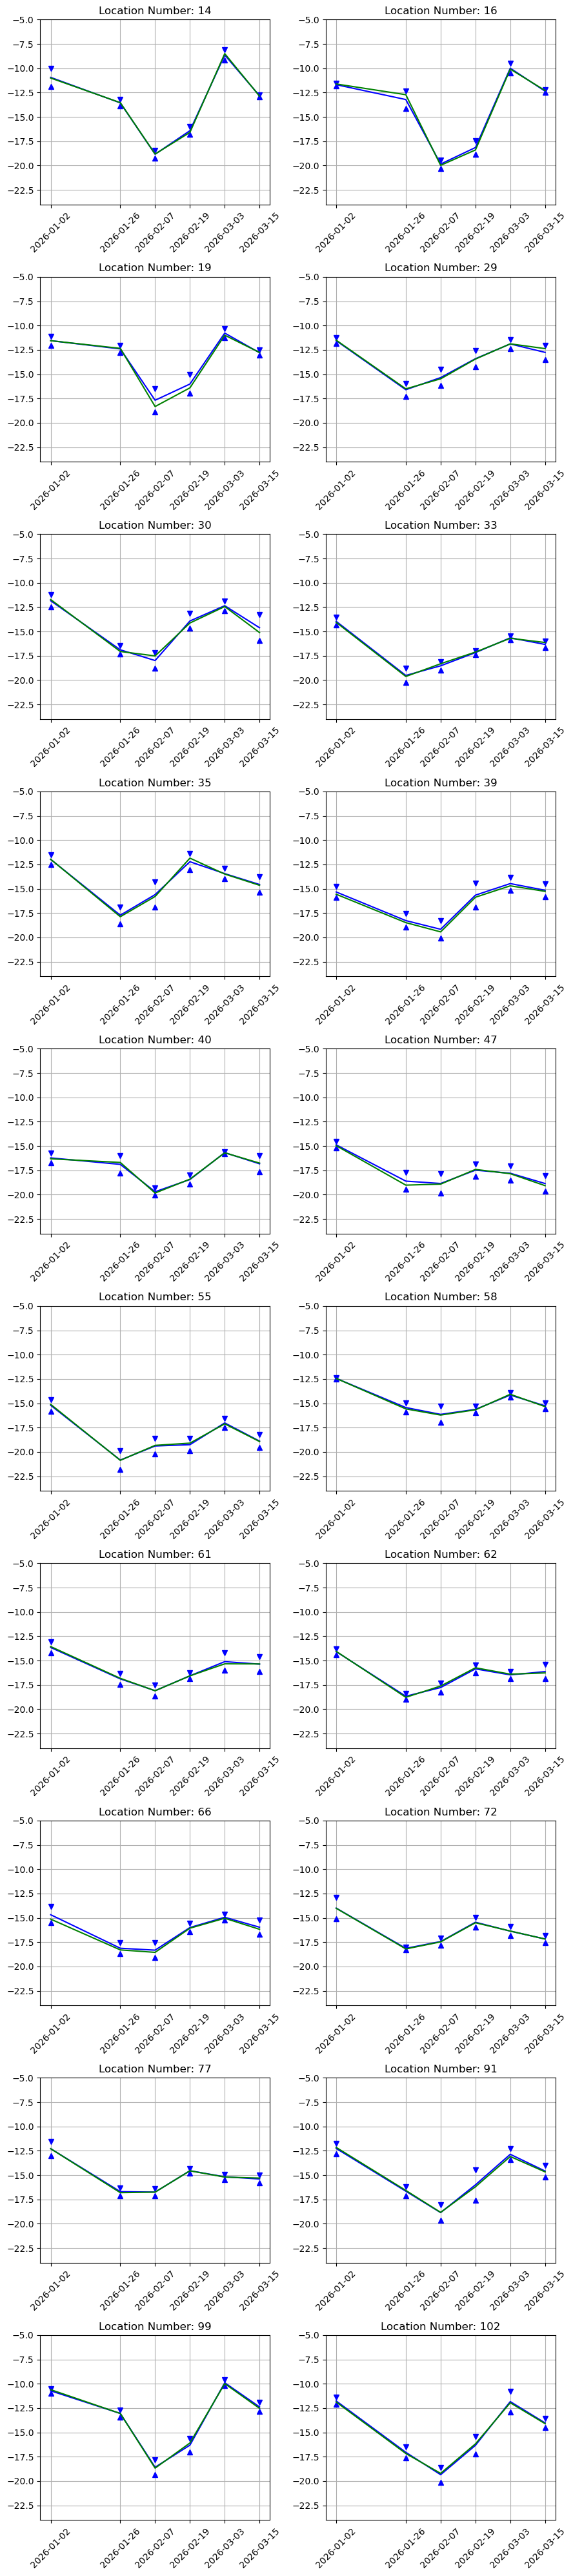

In [89]:
for thresh in myDatas_sastrugi_VV:
    print(thresh)
    plotdBForEachLocation(myDatas_sastrugi_VV[thresh], myDates, ymin = -24., ymax = -5.)

## 5.3 Plot grouped Locations

Plot the grouped locations with annotations.

In [90]:
### Create plotting function for possible overflow! ###
def plotGroupedOverflowProbabilities(da, myDatas, min_neg, cmap = 'viridis'):
    # Function to plot probable overflow locations. 
    # da - single SAR image. 
    # myDatas - dictionary containing the data. 
    # myIndices - list of lists of lists; this contains the indices for each identified possible overflow point for different

    # plot SAR image background. 

    # Create color list based on number of myIndices lists. 
    n_colors = len(min_neg)
    color = cm.rainbow(np.linspace(0, 1, n_colors))
        
    # Loop through the dictionary
    i = 0
    for thresh in myDatas:
        fig = plt.figure(figsize=(12,9))
        plt.imshow(da, cmap='gray', interpolation='None')
        for key in myDatas[thresh]: 
            idx1_temp, idx0_temp = [], []
            for j in range(len(myDatas[thresh][key]['indices'])):
                idx1_temp.append(myDatas[thresh][key]['indices'][j][1])
                idx0_temp.append(myDatas[thresh][key]['indices'][j][0])
            plt.plot(idx1_temp, idx0_temp, color=color[i], marker='.', markersize=1, linestyle='None')
            plt.annotate(f"{key}", xy=(int(np.min(idx1_temp))+10, int(np.max(idx0_temp)-10)))
        
        i = i + 1

        # Add grid lines. 
        plt.title(thresh)
        plt.grid()
        plt.show()
    
    return

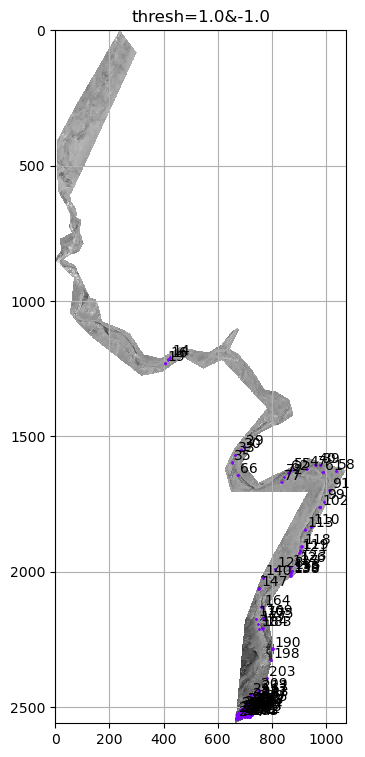

In [92]:
plotGroupedOverflowProbabilities(da_VV_tot[0], myDatas_sastrugi_VV, delta_VV)

### Export locations as a kml file for viewing in a GIS. 

In [93]:
def getLatLon(parent, myData_indices):
    # Function to get latitude and longitude from a geotiff for particular indices. 

    # Input variables: 
    # parent - posix path of the parent directory. 
    # myData_indices - list of lists of the indices. 

    # Output variables: 
    # lat - latitude in degrees. 
    # lon - longitude in degrees. 

    # Get the center index from the list of indices. 
    idx0, idx1 = [], []
    for i in range(len(myData_indices)):
        idx0.append(myData_indices[i][0])
        idx1.append(myData_indices[i][1])
    row = int( np.median( idx0 ) )
    col = int( np.median( idx1 ) )

    # Get a tiff path. 
    folder = parent+'RTC_GAMMA/'
    # Create the path to the tiff directory. 
    tiff_dir = Path(folder)
    # Get all the tiff names from the tiff directory. 
    tiffs = [f for f in os.listdir(tiff_dir)]
    # Put together folder and one tiff into a complete path. 
    myTiffPath = Path(folder, tiffs[0])
    # Open the tiff in order to get the lat/lon. 
    with rasterio.open(myTiffPath) as src: 
        # Get the x and y coordinate from our chosen index. 
        x, y = src.transform * (col, row)
        # Get the coordinate reference system. 
        crs = src.crs
        # Setup object to convert x and y into lat/lon. 
        transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
        # convert x/y to lat/lon. 
        lon, lat = transformer.transform(x,y)
    
    
    return lat, lon

In [95]:
myKml = simplekml.Kml()

for thresh in myDatas_sastrugi_VV:
    for key in myDatas_sastrugi_VV[thresh]:
        lat, lon = getLatLon(fc.selected, myDatas_sastrugi_VV[thresh][key]['indices'])
        # print(f"Lat/Lon: {lat}, {lon}")
        myKml.newpoint(name=f"Location {key}", coords=[(lon, lat)])

    myKml_filename = Path(fc_saveLoc.selected,f"possible-S1-sastrugi_{thresh}_"+str(date.today())+".kml")
    
    myKml.save(myKml_filename)
    
    print(f"KML file saved as: {myKml_filename}")

KML file saved as: /home/jovyan/CRREL/OverflowDetection/Dataset/Kotzebue_10m-desc/subsets_v2/sastrugi/possible-S1-sastrugi_thresh=1.0&-1.0_2026-03-20.kml


### Save overflow locations in a geotiff

In [100]:
def saveSastrugiAsGeotiff(loadLoc, saveLoc, da, min_neg, myIndices, saveName = None):
    # Save overflow as a geotiff

    # Get important GIS info. 
    tiff_dir = Path(loadLoc.selected,'RTC_GAMMA/')
    tiffs = list(tiff_dir.glob(f'*.tif*'))
    raster = rasterio.open(tiffs[0])
    CRS = raster.crs
    transform = raster.transform
    raster.close()

    # Set up empty array
    myGeotiffArray = np.zeros(da.shape, dtype=np.int8)

    # Walk through indices; this goes through reverse. 
    j = 0 # set up a counter that increases. Higher number means higher likelihood of flooding. 
    for i in range(len(myIndices)-1, -1, -1):
        j = j + 1
        idx0 = [sublist[0] for sublist in myIndices[i]]
        idx1 = [sublist[1] for sublist in myIndices[i]]            
        myGeotiffArray[idx0,idx1] = int(j)

    # Set up save settings. 
    profile = {
        'driver': 'GTiff',
        'height': myGeotiffArray.shape[0],
        'width': myGeotiffArray.shape[1],
        'count': 1,
        'dtype': myGeotiffArray.dtype,
        'crs': CRS,
        'transform': transform
    }
    
    # Write data
    if not saveName:
        saveName = Path(saveLoc.selected,'overflow_'+str(date.today())+'.tif')
    else: 
        saveName = Path(saveLoc.selected,saveName+'_'+str(date.today())+'.tif')
    with rasterio.open(saveName, 'w+', **profile, compress='lzw') as dst:
        dst.write(myGeotiffArray, 1)
    
    return myGeotiffArray

To save the file with a different name, set saveName equal to a string. 

For example, <br>
saveOverflowAsGeotiff(fc, fc_saveLoc, da_VV_tot[0], myIndices_both, saveName = 'TananaRiverOverflow')

In [101]:
saveSastrugiAsGeotiff(fc, fc_saveLoc, da_VV_tot[0], delta_VH, myIndices_sastrugi, saveName = saveName)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2560, 1074), dtype=int8)

### 5.4 Selected example of a possible overflow event. 

The below cell plots a possible overflow event from the example data. The possible overflow occurs between <b>2024-11-24</b> and <b>2024-12-06</b>. 

In [ ]:
if 'ExampleDataset' not in fc.selected: 
    print("Example data not loaded, skipping display of overflow example.")
else: 
    print("Displaying overflow example...")
    fig_pof = plt.figure()
    
    ymin = -24.0
    ymax = -14.0
    
    loc = '33'
    plt.plot(myDates, myDatas_v1[loc]['mean'], color='blue')
    plt.plot(myDates, myDatas_v1[loc]['mean']+myDatas_v1[loc]['std'], color='blue', marker='v', linestyle='None')
    plt.plot(myDates, myDatas_v1[loc]['mean']-myDatas_v1[loc]['std'], color='blue', marker='^', linestyle='None')
    plt.plot(myDates, myDatas_v1[loc]['median'], color='green')
    plt.grid()    
    plt.xticks(myDates, myDates, rotation=45)
    plt.title(f"Location Number: {loc}")
    plt.ylim(ymin, ymax)
    
    plt.tight_layout()
    plt.show()

The possible overflow between <b>2024-11-24</b> and <b>2024-12-06</b> shows a typical spike in backscatter followed by a minor decrease. 

***
# 6. Display Data for Possible Overflow Locations

## 6.1. Backscatter Plots

Display plots of selected location. These plots are 1) a plot of backscatter of each pixel for a selected location through time and 2) a plot of SAR image for the local region of the identified location. 

In [ ]:
# plot backscatter and diffs through time for identified indices. 
def plotBSnDiffsThruTime(da_diffs, da_tot, myIndices, start_ind=0, stop_ind=-1):
    num_mI = len(myIndices[start_ind:stop_ind]) + 1
    print(num_mI)

    n_max = 20
    if num_mI > n_max:
        print(f"Too many individual indices.\nPlotting only those from {start_ind} to {start_ind+20}.")
        print("To plot a different range of individual points, set 'start_ind' and 'stop_ind'.")
        num_mI = n_max
    
    # Create subplots. 
    n_cols = 2
    n_rows = int(np.ceil(num_mI))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, n_rows*4))
    
    # Flatten axes array for easier indexing. 
    axes = axes.flatten()
    
    myDates = da_tot.time.values.astype('datetime64[D]')
    myDatePairs = [None] * (len(myDates)-1)
    for i in range(len(myDatePairs)):
        myDatePairs[i] = f"{myDates[i]} & {myDates[i+1]}"
    
    for j in range(start_ind,start_ind+2*num_mI, 2): 
        i = int(j/2)
        # Pull out data for each possible location to a temporary variable for plotting. 
        myData_raw   = da_tot[:, myIndices[i][0], myIndices[i][1]].values
        myData_diffs = da_diffs[:, myIndices[i][0], myIndices[i][1]]
        # Plot the raw data. 
        ax_raw = axes[j]
        ax_raw.plot(myDates, myData_raw)
        # Plot the difference data. 
        ax_diff = axes[j+1]
        ax_diff.plot(myDatePairs, myData_diffs)
    
        # Format plots
        ax_raw.grid()
        ax_diff.grid()
        ax_raw.set_title(f"Raw Data [dB]")
        ax_diff.set_title(f"Differences")
        ax_raw.set_ylabel("Decibels")
        ax_raw.tick_params(axis='x', labelrotation=45)
        ax_diff.tick_params(axis='x', labelrotation=45)
        
    
    plt.tight_layout()
    plt.show()

    return

### <span style="color:red"><b>USER INPUT REQUIRED!!!</b></span>

Please select the location number for your overflow region (loc). 

In [ ]:
for neg in min_neg:
    thresh = f"thresh={neg}"
    print(thresh)
    if len(myDatas_VV[thresh]) == 0:
        continue
    else:
        loc = next(iter(myDatas_VV[thresh]))
        break
myDate = np.datetime64(da_VH_tot.time[-2].values)

In [ ]:
# Display raw backscatter and change in backscatter pairs for all indices in the given location. 
# I don't consider this particularly useful; I include it so users may examine each pixel 
# within a group for strange behavior. 
plotBSnDiffsThruTime(da_diffs_VH[0], da_VH_tot, myDatas_VH[thresh][loc]['indices'])

In [ ]:

plotBSnDiffsThruTime(da_diffs_VV[0], da_VV_tot, myDatas_VV[thresh][loc]['indices'])

In [ ]:
# plot locations for identified indices as pairs (pre-overflow and post-overflow). 

def plotPossOverflowLocations(da, myIndices, DOI, w_s, factor = 30, vmin = -25.0, vmax = -5.0): 

    # plot locations for identified indices as pairs (pre-overflow and post-overflow). 

    # da - input data; xarray expected. 
    # myIndices - identified overflow indices. 
    # DOI - date of interest. Needs to be 
    # w_s - window size; scalar expected. 
    # factor - scale by which to multiple w_s for display; scalar expected. 
    # vmin - minimum values to plot; default is scaled for dB input. 
    # vmax - maximum values to plot; default is scaled for dB input. 

    num_mI = len(myIndices)
    w_s = int(np.floor(w_s/2))
        
    # Create subplots. 
    n_cols = 2
    n_rows = 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, n_rows*4))
    
    # Flatten axes array for easier indexing. 
    axes    = axes.flatten()
    ax_pre  = axes[0]
    ax_post = axes[1]
    
    myDates = da.time.values.astype('datetime64[D]')
    dateIndex = np.where(myDates == DOI)[0][0]
    myDatePair = f"{myDates[dateIndex]} & {myDates[dateIndex+1]}"


    # Pull out data for each possible location to a temporary variable for plotting. 
    idx0 = []
    idx1 = []
    for i in range(len(myIndices)): 
        idx0.append(myIndices[i][0])
        idx1.append(myIndices[i][1])
    idx0 = int(np.median(idx0))
    idx1 = int(np.median(idx1))

    # Get extents to plot
    xmin, xmax = idx1-factor*w_s, idx1+factor*w_s+1
    ymin, ymax = idx0-factor*w_s, idx0+factor*w_s+1
    if xmin < 0: xmin = 0
    if xmax > da.shape[2]: xmax = da.shape[2]
    if ymin < 0: ymin = 0
    if ymax > da.shape[1]: ymax = da.shape[1]

    # plot the pre- and post-overflow data. 
    ax_pre.imshow(da[dateIndex], cmap='gray', interpolation=None, vmin=vmin, vmax=vmax)
    ax_post.imshow(da[dateIndex+1], cmap='gray', interpolation=None, vmin=vmin, vmax=vmax)
    # Constrain the view to the location of interest. 
    ax_pre.set_xlim(xmin, xmax)
    ax_pre.set_ylim(ymin, ymax)
    ax_post.set_xlim(xmin, xmax)
    ax_post.set_ylim(ymin, ymax)
    # Plot the position of the point of change. 
    ax_pre.plot(idx1, idx0, marker='o', markersize=20, fillstyle='none', linestyle='None')
    ax_post.plot(idx1, idx0, marker='o', markersize=20, fillstyle='none', linestyle='None')
    # Correct y axis flip; using imshow and then .plot will flip the y axis so north is down. 
    ax_pre.invert_yaxis()
    ax_post.invert_yaxis()

    # Format plots
    ax_pre.grid()
    ax_post.grid()
    ax_pre.set_title(f"Pre-Overflow\nDate: {myDates[dateIndex]}")
    ax_post.set_title(f"Post-Overflow\nDate: {myDates[dateIndex+1]}")
        
    
    plt.tight_layout()
    plt.show()

    return

In [ ]:
# Display the pre- and post-overflow SAR image for a given date. 
# plotPossOverflowLocations(da_VH_tot, myDatas_VH[loc]['indices'], myDate, window_sizes[0], factor=3)
plotPossOverflowLocations(da_VH_tot, myDatas_VH[thresh][loc]['indices'], myDate, window_sizes[0], factor=20)
plotPossOverflowLocations(da_VV_tot, myDatas_VV[thresh][loc]['indices'], myDate, window_sizes[0], factor=20)

In [ ]:
# Display all of the SAR image pairs for a given location. 

for myDate in myDates[0:-1]:
    print(f'Set for {myDate}')
    # plotPossOverflowLocations(da_VH_tot, myDatas_VH[loc]['indices'], myDate, window_sizes[0], factor=3)
    plotPossOverflowLocations(da_VH_tot, myDatas_VH[thresh][loc]['indices'], myDate, window_sizes[0], factor=30)
    print(f'\n\n\n')

In [ ]:
# Display all of the SAR image pairs for a given location. 

for myDate in myDates[0:-1]:
    print(f'Set for {myDate}')
    # plotPossOverflowLocations(da_VV_tot, myDatas_VV[loc]['indices'], myDate, window_sizes[0], factor=3)
    plotPossOverflowLocations(da_VV_tot, myDatas_VV[thresh][loc]['indices'], myDate, window_sizes[0], factor=30)
    print(f'\n\n\n')

## 6.2. False Color Plots of Selected Location

The below code will plot the local region of the identified location in false color imagery. This is meant to help non-SAR experts more easily identify changes in the select location. 

This is done in two different ways. 

1. 'both' - Pre-overflow in red, post-overflow in green.
2. 'all'  - Pre-overflow in red, during in green, and post-overflow in blue.

It is important to note that the post-overflow (green) of option 1. corresponds to the during (green) of option 2. 

Option 1. ('both') appears to be the most useful in visually identifying possible overflow. Overflow locations will generally appear as red; new ice as cyan and old ice as a light gray; and water as a dark gray. 

In [ ]:
# Create function to plot pre-overflow in red and post-overflow in green. 
def falseColor(da, myIndices, DOI, w_s, option = 'all', factor = 30, vmin = -25.0, vmax = -5.0): 

    # plot locations for identified indices as pairs (pre-overflow and post-overflow). 

    # da - input data; xarray expected. 
    # myIndices - identified overflow indices. 
    # DOI - date of interest. Needs to be 
    # w_s - window size; scalar expected. 
    # factor - scale by which to multiple w_s for display; scalar expected. 
    # vmin - minimum values to plot; default is scaled for dB input. 
    # vmax - maximum values to plot; default is scaled for dB input. 
    # option - if 'both', the before and after are used for RGB plotting; if 'all', the before, during, and after are used. 

    fig_fC, ax_fC = plt.subplots(1, 1, figsize=(9, 4))

    myDates = da.time.values.astype('datetime64[D]')
    dateIndex = np.where(myDates == DOI)[0][0]

    # Pull out data for each possible location to a temporary variable for plotting. 
    idx0 = []
    idx1 = []
    for i in range(len(myIndices)): 
        idx0.append(myIndices[i][0])
        idx1.append(myIndices[i][1])
    idx0 = int(np.median(idx0))
    idx1 = int(np.median(idx1))
    
    # Get extents to plot
    xmin, xmax = idx1-factor*w_s, idx1+factor*w_s+1
    ymin, ymax = idx0-factor*w_s, idx0+factor*w_s+1
    if xmin < 0: xmin = 0
    if xmax > da.shape[2]: xmax = da.shape[2]
    if ymin < 0: ymin = 0
    if ymax > da.shape[1]: ymax = da.shape[1]

    red = da[dateIndex].values
    green = da[dateIndex+1].values
    if option == 'both':
        blue = np.zeros(green.shape)
        myDatePair = f"{myDates[dateIndex]}=red, {myDates[dateIndex+1]}=green"
    elif option == 'all':
        blue = da[dateIndex+2].values
        myDatePair = f"{myDates[dateIndex]}=red, {myDates[dateIndex+1]}=green, {myDates[dateIndex+2]}=blue"

    # scale red and blue from 0 to 1. 
    def scaleMinMax(x):
        return((x - np.nanmin(x))/(np.nanmax(x) - np.nanmin(x)))
    
    red = scaleMinMax(red)
    red = red * red
    green = scaleMinMax(green)
    green = green * green
    if option == 'both':
        # blue[:] = np.nanmedian(green)
        blue = 1. / np.sqrt( red*red + green*green )
        blue = scaleMinMax(blue)
    if option == 'all':
        blue = scaleMinMax(blue)
        blue = blue * blue

    rg = np.dstack((red,green, blue))
    
    # plot the pre- and post-overflow data. 
    # ax_fC.imshow(da[dateIndex], cmap='Reds', interpolation=None, vmin=vmin, vmax=vmax)
    # ax_fC.imshow(da[dateIndex+1], cmap='Greens', interpolation=None, vmin=vmin, vmax=vmax)
    ax_fC.imshow(rg)
    # Constrain the view to the location of interest. 
    ax_fC.set_xlim(xmin, xmax)
    ax_fC.set_ylim(ymin, ymax)
    # Plot the position of the point of change. 
    ax_fC.plot(idx1, idx0, marker='o', color='black', markersize=20, fillstyle='none', linestyle='None')
    ax_fC.plot(idx1, idx0, marker='o', color='black', markersize=20, fillstyle='none', linestyle='None')
    # Correct y axis flip; using imshow and then .plot will flip the y axis so north is down. 
    ax_fC.invert_yaxis()
    
    # Format plots
    ax_fC.grid()
    ax_fC.set_title(f"Pre-Overflow\nDates: {myDatePair}")
        
    
    plt.tight_layout()
    plt.show()

    return

In [ ]:
for myDate in myDates[0:-1]:
    falseColor(da_VV_tot, myDatas_VV[thresh][loc]['indices'], myDate, window_sizes[0], option='both', factor=15)

In [ ]:
for myDate in myDates[0:-1]:
    falseColor(da_VH_tot, myDatas_VH[thresh][loc]['indices'], myDate, window_sizes[0], option='both', factor=15)

In [ ]:
for myDate in myDates[0:-2]:
    falseColor(da_VH_tot, myDatas_VV[thresh][loc]['indices'], myDate, window_sizes[0], option='all', factor=15)

In [ ]:
for myDate in myDates[0:-2]:
    falseColor(da_VV_tot, myDatas_VV[thresh][loc]['indices'], myDate, window_sizes[0], option='all', factor=15)